In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import joblib

# Import sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
# Download dataset directly from Kaggle
path = kagglehub.dataset_download(
    "shree1992/housedata"
)

# Read dataset
df = pd.read_csv(f"{path}/data.csv")

# Show dataset
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
# Dataset shape
df.shape

(4600, 18)

In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [5]:
# Check missing values
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [6]:
# Remove duplicates
df = df.drop_duplicates()

In [7]:
# Drop unnecessary columns
drop_cols = ["date", "street", "country"]

# Drop columns if present
for col in drop_cols:

    # Check column exists
    if col in df.columns:

        # Drop column
        df = df.drop(col, axis=1)

# Show dataset
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052


In [8]:
# Create classification target
median_price = df["price"].median()

# Create price category
df["price_category"] = np.where(
    df["price"] >= median_price,
    1,
    0
)

# Drop original price column
df = df.drop("price", axis=1)

# Show dataset
df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,price_category
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,0
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,1
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,0
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008,0
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052,1


In [9]:
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Categorical columns
cat_cols = df.select_dtypes(include="object").columns

In [10]:
# Fill numerical missing values
num_imputer = SimpleImputer(strategy="mean")

# Transform numerical columns
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Fill categorical missing values
cat_imputer = SimpleImputer(strategy="most_frequent")

# Transform categorical columns
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [11]:
# Store encoders
encoders = {}

# Encode categorical columns
for col in cat_cols:

    # Create encoder
    le = LabelEncoder()

    # Encode values
    df[col] = le.fit_transform(df[col])

    # Store encoder
    encoders[col] = le

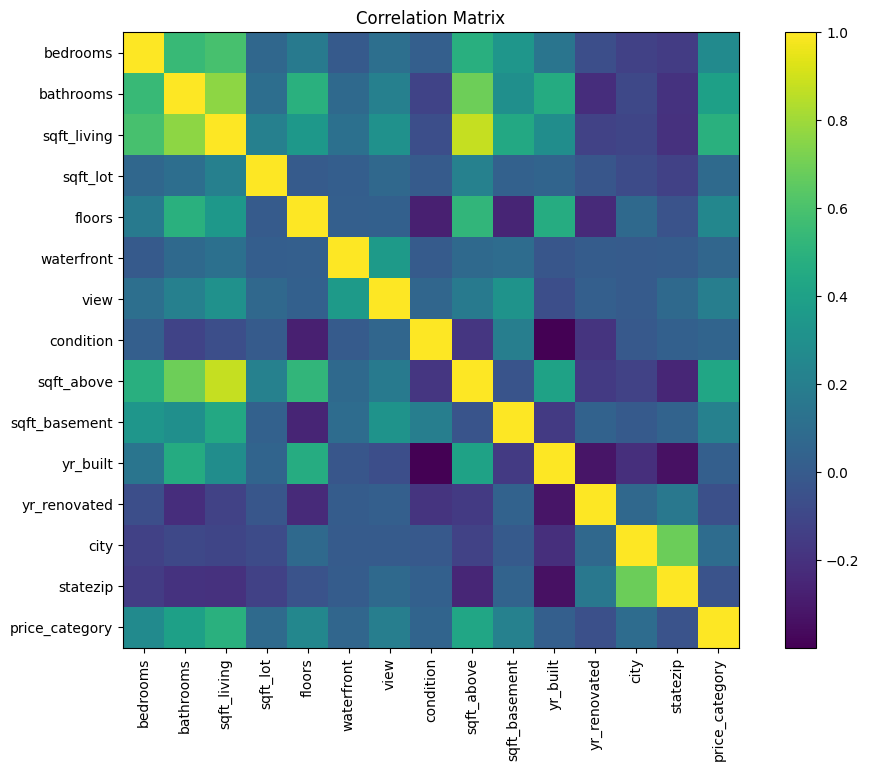

In [12]:
# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation matrix
corr = numeric_df.corr()

# Create figure
plt.figure(figsize=(12, 8))

# Plot heatmap
plt.imshow(corr)

# Labels
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

# Colorbar
plt.colorbar()

# Title
plt.title("Correlation Matrix")

# Show graph
plt.show()

In [13]:
# Features
X = df.drop("price_category", axis=1)

# Target
y = df["price_category"]

In [14]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Show shapes
print(X_train.shape)
print(X_test.shape)

(3680, 14)
(920, 14)


In [15]:
# Scale dataset
scaler = StandardScaler()

# Fit train data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [16]:
# Parameter grid
param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

In [18]:
# Create model
knn = KNeighborsClassifier()

# GridSearchCV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy"
)

In [20]:
# Train model
grid_search.fit(X_train_scaled, y_train)

# Best model
model = grid_search.best_estimator_

# Show best parameters
grid_search.best_params_

# Save model
joblib.dump(model, "models/knn_classifier.pkl")

# Save scaler
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [22]:
# Predict output
y_pred = model.predict(X_test_scaled)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Show accuracy
accuracy



0.7967391304347826

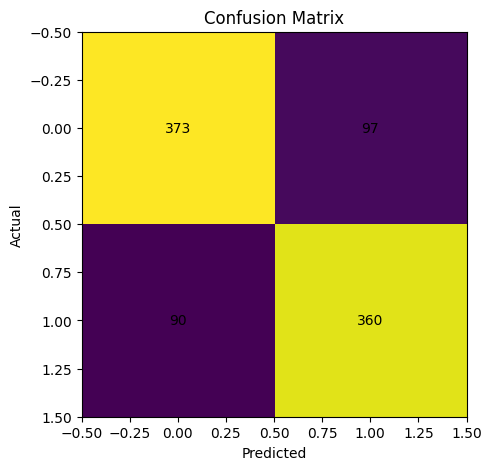

In [23]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create figure
plt.figure(figsize=(5, 5))

# Plot matrix
plt.imshow(cm)

# Labels
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add values
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

# Title
plt.title("Confusion Matrix")

# Show graph
plt.show()

In [24]:
# Classification report
report = classification_report(
    y_test,
    y_pred
)

# Show report
print(report)

              precision    recall  f1-score   support

         0.0       0.81      0.79      0.80       470
         1.0       0.79      0.80      0.79       450

    accuracy                           0.80       920
   macro avg       0.80      0.80      0.80       920
weighted avg       0.80      0.80      0.80       920

